<p style="font-size: 20px;">
<b>Student Full Name:</b> Jasser Dhaouadi <br>
<b>Student ID:</b> U89818600 <br>
<b>Course:</b> Data Science Capstone - 1 <br>
<b>Semester:</b> Summer 2026 <br>
<b>Program:</b> OMDS <br>
<b>Boston University</b> 
</p>

# Week 4 - Logistic Regression and Feature Scaling

# Homework - Working On My Datasets

### Packages

In [89]:
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    classification_report,
    confusion_matrix
)
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

### IMPORTANT NOTE:

- In this notebook, I am applying the Week 4 concepts to my datasets.

- The main concepts are **logistic regression** and **feature scaling**. 

- Since the target variables of my datasets are categorical, **logistic regression is appropriate**


## Dataset 1: CDC Diabetes Health Indicators  (sourced from BRFSS) 

#### [Dataset 1] | *1- Load the dataset*

In [90]:
diabetes_path = "diabetes_012_health_indicators_BRFSS2015.csv"

df_diabetes = pd.read_csv(diabetes_path)

print("Dataset shape:", df_diabetes.shape)
display(df_diabetes.head())

target = "Diabetes_012"

class_counts = df_diabetes[target].value_counts().sort_index()
class_percent = (class_counts / len(df_diabetes) * 100).round(2)

class_summary = pd.DataFrame({
    "Class Count": class_counts.astype(int),
    "Percent": class_percent
})

display(class_summary)

Dataset shape: (253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


,Class Count,Percent
Diabetes_012,,
0.0,213703,84.24
1.0,4631,1.83
2.0,35346,13.93



- The **target** is highly **imbalanced**:
    - Class 0 dominates the dataset
    - while class 1 is very rare

- Because of this, accuracy alone is not enough: Balanced accuracy, macro F1, and multiclass ROC AUC are used to better evaluate the models.

#### [Dataset 1] | *2- Train-test split*

In [91]:
X = df_diabetes.drop(columns=[target])
y = df_diabetes[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

display(y_train.value_counts().sort_index().to_frame("Train Class Count"))
display(y_test.value_counts().sort_index().to_frame("Test Class Count"))

Training shape: (202944, 21)
Testing shape: (50736, 21)


,Train Class Count
Diabetes_012,
0,170962
1,3705
2,28277


,Test Class Count
Diabetes_012,
0,42741
1,926
2,7069


- The data was split into training and testing sets using **stratification**.


| Split | Shape |
|---|---:|
| Training | (202,944, 21) |
| Testing | (50,736, 21) |


- **Stratification** is important because the prediabetes class is very small
    - This keeps the **class distribution similar in both the training and testing sets**.

#### [Dataset 1] | *3- Investigate feature scales*

In [92]:
scale_summary = pd.DataFrame({
    "Feature": X.columns,
    "Minimum": X.min().values,
    "Maximum": X.max().values,
    "Mean": X.mean().values,
    "Std": X.std().values
})

scale_summary["Range"] = scale_summary["Maximum"] - scale_summary["Minimum"]

display(
    scale_summary
    .sort_values("Range", ascending=False)
    .head(10)
)

,Feature,Minimum,Maximum,Mean,Std,Range
3,BMI,12.0,98.0,28.382364,6.608694,86.0
14,MentHlth,0.0,30.0,3.184772,7.412847,30.0
15,PhysHlth,0.0,30.0,4.242081,8.717951,30.0
18,Age,1.0,13.0,8.032119,3.054220,12.0
20,Income,1.0,8.0,6.053875,2.071148,7.0
19,Education,1.0,6.0,5.050434,0.985774,5.0
13,GenHlth,1.0,5.0,2.511392,1.068477,4.0
1,HighChol,0.0,1.0,0.424121,0.494210,1.0
0,HighBP,0.0,1.0,0.429001,0.494934,1.0
4,Smoker,0.0,1.0,0.443169,0.496761,1.0


- The **feature-scale summary** showed that the largest feature ranges were:

| Feature | Minimum | Maximum | Mean | Std | Range |
|---|---:|---:|---:|---:|---:|
| BMI | 12.0 | 98.0 | 28.382 | 6.609 | 86.0 |
| MentHlth | 0.0 | 30.0 | 3.185 | 7.413 | 30.0 |
| PhysHlth | 0.0 | 30.0 | 4.242 | 8.718 | 30.0 |
| Age | 1.0 | 13.0 | 8.032 | 3.054 | 12.0 |
| Income | 1.0 | 8.0 | 6.054 | 2.071 | 7.0 |
| Education | 1.0 | 6.0 | 5.050 | 0.986 | 5.0 |
| GenHlth | 1.0 | 5.0 | 2.511 | 1.068 | 4.0 |

- This confirms why feature scaling matters
    - Some predictors, such as **BMI**, **MentHlth**, and **PhysHlth**, have much **larger ranges** than **binary predictors** such as **HighBP** or **Smoker**
    
    - Without scaling, **gradient-based logistic regression** can give too much numerical influence to large-scale features

#### [Dataset 1] | *4- Visualize feature ranges*

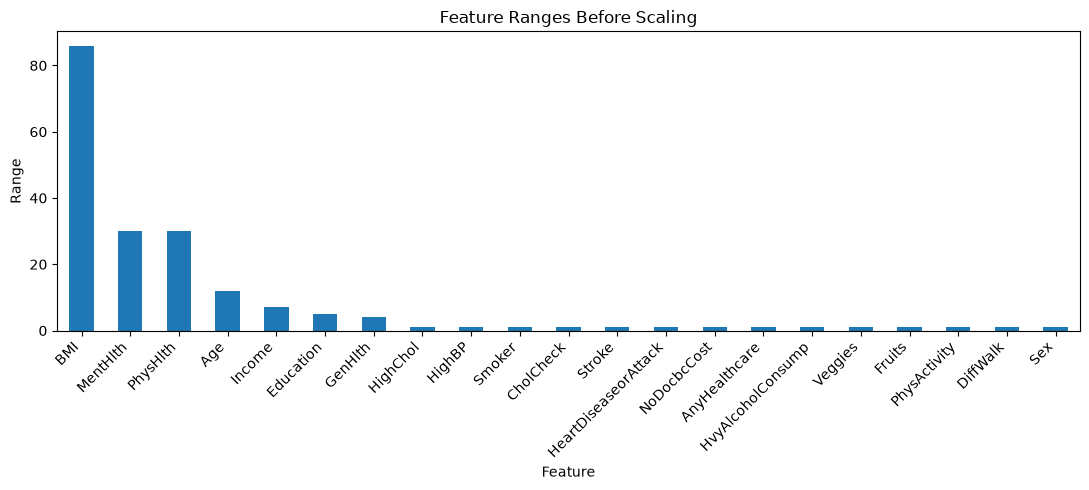

In [93]:
scale_summary.sort_values("Range", ascending=False).plot(
    x="Feature",
    y="Range",
    kind="bar",
    figsize=(11, 5),
    legend=False
)

plt.title("Feature Ranges Before Scaling")
plt.xlabel("Feature")
plt.ylabel("Range")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

- The **feature-range plot** visually confirms that the predictors are **not** on the same scale

    - **BMI** has the largest range, followed by **MentHlth** and **PhysHlth**
    
    - Many other predictors are **binary** with a range of only 1. 
    

- This supports the **Week 4 idea that scaling is important before logistic regression**, especially when the model is trained using **gradient-based optimization**


#### [Dataset 1] | *5- Define model evaluation function*

In [94]:
def evaluate_logistic_model(model_name, model):
    start_time = time.time()
    
    model.fit(X_train, y_train)
    
    fit_time = time.time() - start_time
    
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)
    
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_test, predictions),
        "Macro F1": f1_score(y_test, predictions, average="macro"),
        "Weighted F1": f1_score(y_test, predictions, average="weighted"),
        "Macro OVR ROC AUC": roc_auc_score(
            y_test,
            probabilities,
            multi_class="ovr",
            average="macro"
        ),
        "Log Loss": log_loss(
            y_test,
            probabilities,
            labels=[0, 1, 2]
        ),
        "Iterations": int(model.named_steps["sgd_logit"].n_iter_),
        "Fit Time Seconds": fit_time
    }
    
    return metrics, predictions, probabilities, model

- This **helper function** trains a **logistic regression model**, **generates predictions**, and **calculates evaluation metrics**

- The important Week 4 **metrics** here are:

    - **Log loss**, which is connected to cross-entropy loss
    - **Number of iterations**, which helps show whether scaling improves optimization
    - **Fit time**, which helps show whether scaling makes training faster

- The **classification metrics** are also included because this is a **multiclass health classification problem**

#### [Dataset 1] | *6- Compare no scaling, standardization, and normalization*

In [95]:
scaling_models = {
    "No scaling": Pipeline(
        steps=[
            ("sgd_logit", SGDClassifier(
                loss="log_loss",
                penalty="l2",
                alpha=0.0001,
                class_weight="balanced",
                max_iter=1000,
                tol=1e-3,
                random_state=42
            ))
        ]
    ),
    "Standardization": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("sgd_logit", SGDClassifier(
                loss="log_loss",
                penalty="l2",
                alpha=0.0001,
                class_weight="balanced",
                max_iter=1000,
                tol=1e-3,
                random_state=42
            ))
        ]
    ),
    "Normalization": Pipeline(
        steps=[
            ("scaler", MinMaxScaler()),
            ("sgd_logit", SGDClassifier(
                loss="log_loss",
                penalty="l2",
                alpha=0.0001,
                class_weight="balanced",
                max_iter=1000,
                tol=1e-3,
                random_state=42
            ))
        ]
    )
}

scaling_results = []
scaling_predictions = {}
scaling_probabilities = {}
scaling_fitted_models = {}

for model_name, model in scaling_models.items():
    metrics, predictions, probabilities, fitted_model = evaluate_logistic_model(
        model_name,
        model
    )
    
    scaling_results.append(metrics)
    scaling_predictions[model_name] = predictions
    scaling_probabilities[model_name] = probabilities
    scaling_fitted_models[model_name] = fitted_model

scaling_results_df = pd.DataFrame(scaling_results)

display(scaling_results_df)

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro OVR ROC AUC,Log Loss,Iterations,Fit Time Seconds
0,No scaling,0.824306,0.440164,0.441131,0.816051,0.773831,0.522263,264,16.333993
1,Standardization,0.812382,0.443859,0.445871,0.812854,0.770720,0.579916,39,2.156916
2,Normalization,0.810608,0.457150,0.455479,0.813020,0.779687,0.602797,25,1.462667


- The **scaling comparison** was:

| Model | Accuracy | Balanced Accuracy | Macro F1 | Weighted F1 | Macro OVR ROC AUC | Log Loss | Iterations | Fit Time Seconds |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| No scaling | 0.824267 | 0.440070 | 0.441047 | 0.816002 | 0.773834 | 0.522215 | 264 | 20.353 |
| Standardization | 0.812382 | 0.443859 | 0.445871 | 0.812854 | 0.770720 | 0.579916 | 39 | 2.055 |
| Normalization | 0.810608 | 0.457150 | 0.455479 | 0.813020 | 0.779687 | 0.602797 | 25 | 2.325 |

- The strongest result by **macro F1** was **normalization**, with **macro F1 = 0.455479**. It also had the **best balanced accuracy** and **best ROC AUC** among the three scaling options

- The **no-scaling** model had the **highest raw accuracy** and **lowest log loss**, but it required **264 iterations** and about **20.4 seconds** to fit

- The **normalized** model used only **25 iterations and about 2.0 seconds**

    - This strongly supports the Week 4 point that **scaling can speed up gradient-based logistic regression**

#### [Dataset 1] | *7- Visualize scaling comparison*

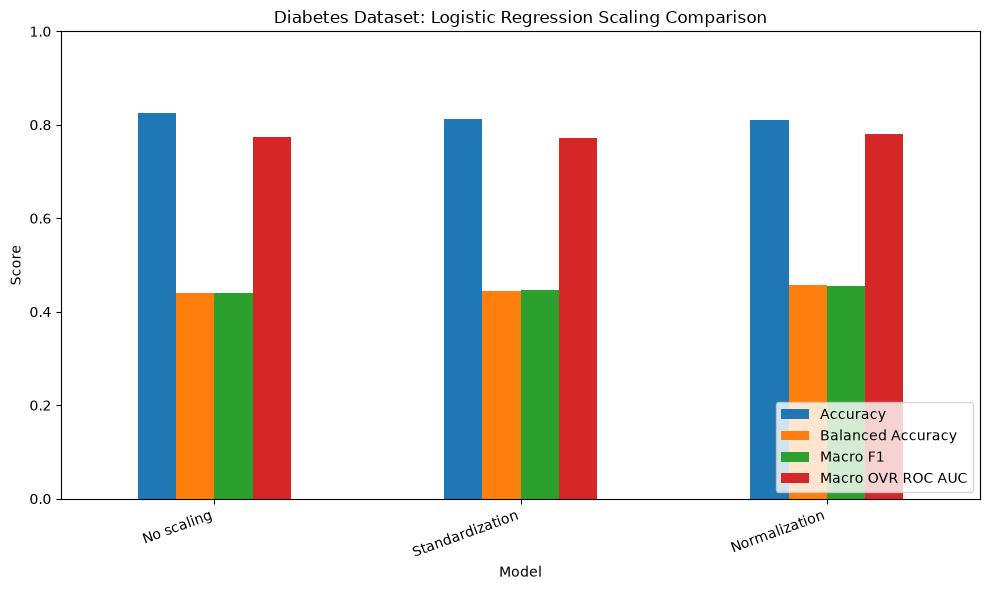

In [96]:
scaling_results_df.set_index("Model")[
    ["Accuracy", "Balanced Accuracy", "Macro F1", "Macro OVR ROC AUC"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Diabetes Dataset: Logistic Regression Scaling Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

- The **scaling comparison plot** shows that the three models are close on some metrics, but **normalization performs best on balanced accuracy, macro F1, and ROC AUC**

- This matters because the **diabetes dataset is imbalanced**

- The **no-scaling** model has higher accuracy, but accuracy is heavily influenced by the majority class

- The **normalized model** gives **slightly better performance** across classes.

#### [Dataset 1] | *8- Visualize optimization speed*

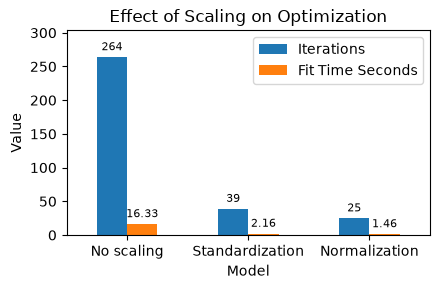

In [106]:
cols = ["Iterations", "Fit Time Seconds"]

ax = scaling_results_df.set_index("Model")[cols].plot(
    kind="bar",
    figsize=(4.5, 3)
)

# Add bar values
for col, container in zip(cols, ax.containers):
    if col == "Iterations":
        labels = [f"{v.get_height():.0f}" for v in container]
    else:
        labels = [f"{v.get_height():.2f}" for v in container]

    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=8
    )

plt.title("Effect of Scaling on Optimization")
plt.ylabel("Value")
plt.xticks(rotation=0, ha="center")

# Add space above bars so labels fit
plt.ylim(0, scaling_results_df[cols].to_numpy().max() * 1.15)

plt.tight_layout()
plt.show()

- This plot shows the s**trongest practical impact of feature scaling**

    - The **no-scaling model** required **264** iterations
    
    - The **standardized model** required **39** iterations
    
    - The **normalized model** required only **25 iterations** 
    
    - **Fit time** also dropped from about **20.4 seconds without scaling to about 2.0 seconds with normalization**

- This directly supports the Week 4 lesson: **scaling helps gradient-based algorithms converge faster** and reduces the risk that large-scale features dominate the optimization path

#### [Dataset 1] | *9- Compare L1, L2, and Elastic Net logistic regression after standardization*

In [64]:
regularized_models = {
    "L1 logistic regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("sgd_logit", SGDClassifier(
                loss="log_loss",
                penalty="l1",
                alpha=0.0001,
                class_weight="balanced",
                max_iter=1000,
                tol=1e-3,
                random_state=42
            ))
        ]
    ),
    "L2 logistic regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("sgd_logit", SGDClassifier(
                loss="log_loss",
                penalty="l2",
                alpha=0.0001,
                class_weight="balanced",
                max_iter=1000,
                tol=1e-3,
                random_state=42
            ))
        ]
    ),
    "Elastic-net logistic regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("sgd_logit", SGDClassifier(
                loss="log_loss",
                penalty="elasticnet",
                l1_ratio=0.5,
                alpha=0.0001,
                class_weight="balanced",
                max_iter=1000,
                tol=1e-3,
                random_state=42
            ))
        ]
    )
}

regularized_results = []
regularized_predictions = {}
regularized_probabilities = {}
regularized_fitted_models = {}

for model_name, model in regularized_models.items():
    metrics, predictions, probabilities, fitted_model = evaluate_logistic_model(
        model_name,
        model
    )
    
    coefficients = fitted_model.named_steps["sgd_logit"].coef_
    active_mask = np.any(np.abs(coefficients) > 1e-8, axis=0)
    
    metrics["Active Features"] = int(active_mask.sum())
    metrics["Zeroed Features"] = int(X.shape[1] - active_mask.sum())
    
    regularized_results.append(metrics)
    regularized_predictions[model_name] = predictions
    regularized_probabilities[model_name] = probabilities
    regularized_fitted_models[model_name] = fitted_model

regularized_results_df = pd.DataFrame(regularized_results)

display(regularized_results_df)

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro OVR ROC AUC,Log Loss,Iterations,Fit Time Seconds,Active Features,Zeroed Features
0,L1 logistic regression,0.777357,0.446013,0.423208,0.793749,0.773773,0.612549,29,2.304460,17,4
1,L2 logistic regression,0.812382,0.443859,0.445871,0.812854,0.770720,0.579916,39,2.238018,21,0
2,Elastic-net logistic regression,0.777259,0.446052,0.423234,0.793705,0.773767,0.612576,29,2.306492,18,3


- The executed **regularization** comparison **after standardization** was:

| Model | Accuracy | Balanced Accuracy | Macro F1 | Weighted F1 | Macro OVR ROC AUC | Log Loss | Iterations | Active Features | Zeroed Features |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| **L1 logistic regression** | 0.777357 | 0.446013 | 0.423208 | 0.793749 | 0.773773 | 0.612549 | 29 | 17 | 4 |
| **L2 logistic regression**| 0.812382 | 0.443859 | 0.445871 | 0.812854 | 0.770720 | 0.579916 | 39 | 21 | 0 |
| **Elastic-net logistic regression** | 0.777259 | 0.446052 | 0.423234 | 0.793705 | 0.773767 | 0.612576 | 29 | 18 | 3 |


- The **L2 model** had the **best macro F1**, while the **L1** and **Elastic-net** models **removed some features**

- **Scaling** is important before applying **L1** or **L2** penalties because the penalty should treat coefficients fairly

    - **L1** removed 4 predictors
    - **Elastic Net** removed 3 predictors
    - **L2** kept all 21 predictors active

#### [Dataset 1] | *10- Visualize regularization comparison*

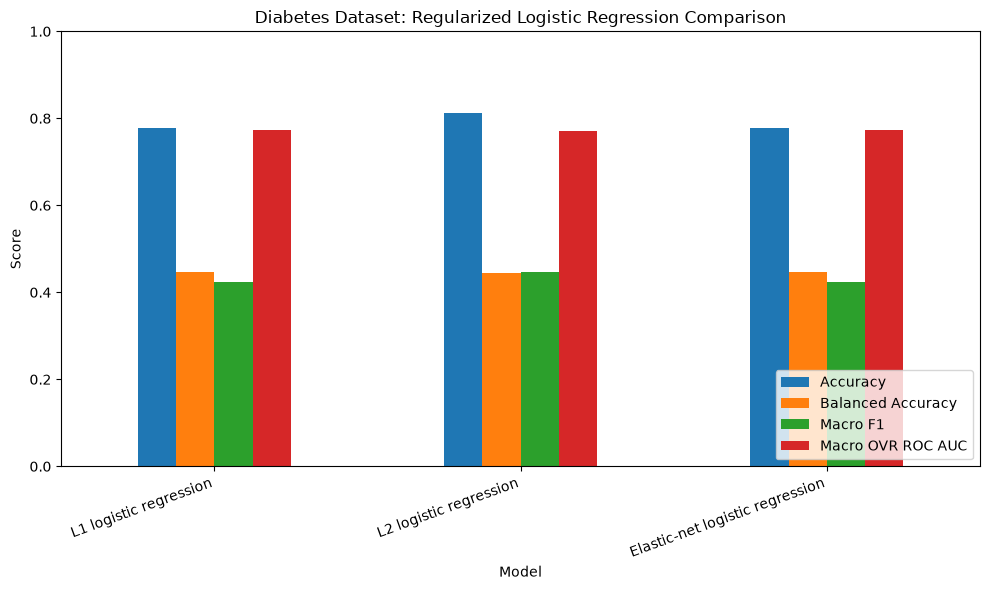

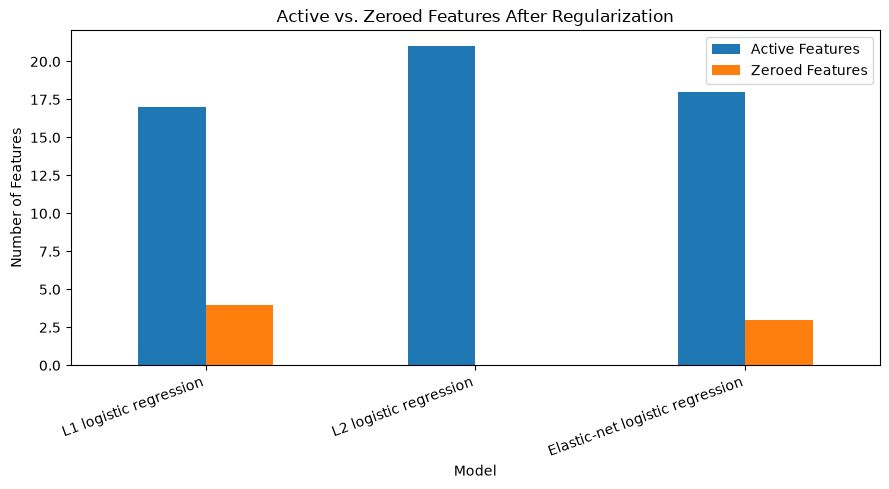

In [65]:
regularized_results_df.set_index("Model")[
    ["Accuracy", "Balanced Accuracy", "Macro F1", "Macro OVR ROC AUC"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Diabetes Dataset: Regularized Logistic Regression Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

regularized_results_df.set_index("Model")[
    ["Active Features", "Zeroed Features"]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Active vs. Zeroed Features After Regularization")
plt.ylabel("Number of Features")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

- The first plot compares **predictive performance** across **L1**, **L2**, and **Elastic-net logistic regression**

- The second plot shows **feature activity**

    - **L1** and **Elastic Net** performed **feature selection** by shrinking some coefficients to zero
    
    - **L2** did not remove features but still shrank coefficient magnitudes

- For this dataset, **L2** gave the strongest **macro F1**, suggesting that keeping all predictors while shrinking their coefficients worked better than removing predictors

#### [Dataset 1] | *11- Inspect standardized logistic regression coefficients*

In [66]:
standardized_model = scaling_fitted_models["Standardization"]

coef_df = pd.DataFrame(
    standardized_model.named_steps["sgd_logit"].coef_,
    index=[
        f"Class {class_label}"
        for class_label in standardized_model.named_steps["sgd_logit"].classes_
    ],
    columns=X.columns
)

top_positive_diabetes = (
    coef_df
    .loc["Class 2"]
    .sort_values(ascending=False)
    .head(12)
)

top_negative_diabetes = (
    coef_df
    .loc["Class 2"]
    .sort_values(ascending=True)
    .head(12)
)

print("Top positive coefficients for Class 2: Diabetes")
display(top_positive_diabetes)

print("Top negative coefficients for Class 2: Diabetes")
display(top_negative_diabetes)

Top positive coefficients for Class 2: Diabetes


GenHlth                 0.562661
BMI                     0.484127
Age                     0.408675
HighBP                  0.373005
CholCheck               0.304806
HighChol                0.293802
Sex                     0.181627
PhysHlth                0.069048
DiffWalk                0.015641
Education              -0.006444
PhysActivity           -0.008047
HeartDiseaseorAttack   -0.008062
Name: Class 2, dtype: float64

Top negative coefficients for Class 2: Diabetes


Income                 -0.152759
HvyAlcoholConsump      -0.098919
Smoker                 -0.071800
Fruits                 -0.069261
AnyHealthcare          -0.042080
MentHlth               -0.037437
NoDocbcCost            -0.037220
Veggies                -0.022275
Stroke                 -0.013020
HeartDiseaseorAttack   -0.008062
PhysActivity           -0.008047
Education              -0.006444
Name: Class 2, dtype: float64

- Using the **standardized logistic regression model**, the **strongest positive coefficients** for **class 2**, diabetes, were:

| Feature | Coefficient |
|---|---:|
| GenHlth | 0.562661 |
| BMI | 0.484127 |
| Age | 0.408675 |
| HighBP | 0.373005 |
| CholCheck | 0.304806 |
| HighChol | 0.293802 |
| Sex | 0.181627 |
| PhysHlth | 0.069048 |
| DiffWalk | 0.015641 |

The strongest negative coefficients were:

| Feature | Coefficient |
|---|---:|
| Income | -0.152759 |
| HvyAlcoholConsump | -0.098919 |
| Smoker | -0.071800 |
| Fruits | -0.069261 |
| AnyHealthcare | -0.042080 |
| MentHlth | -0.037437 |
| NoDocbcCost | -0.037220 |
| Veggies | -0.022275 |
| Stroke | -0.013020 |

- Since the model used **standardization**, these coefficients are easier to compare

    - `GenHlth`, `BMI`, `Age`, `HighBP`, and `HighChol` were the strongest positive predictors for the diabetes class


- **NOTE** : These are **predictive** relationships, **NOT causal** claims

#### [Dataset 1] | *12- Visualize top coefficients for diabetes class*

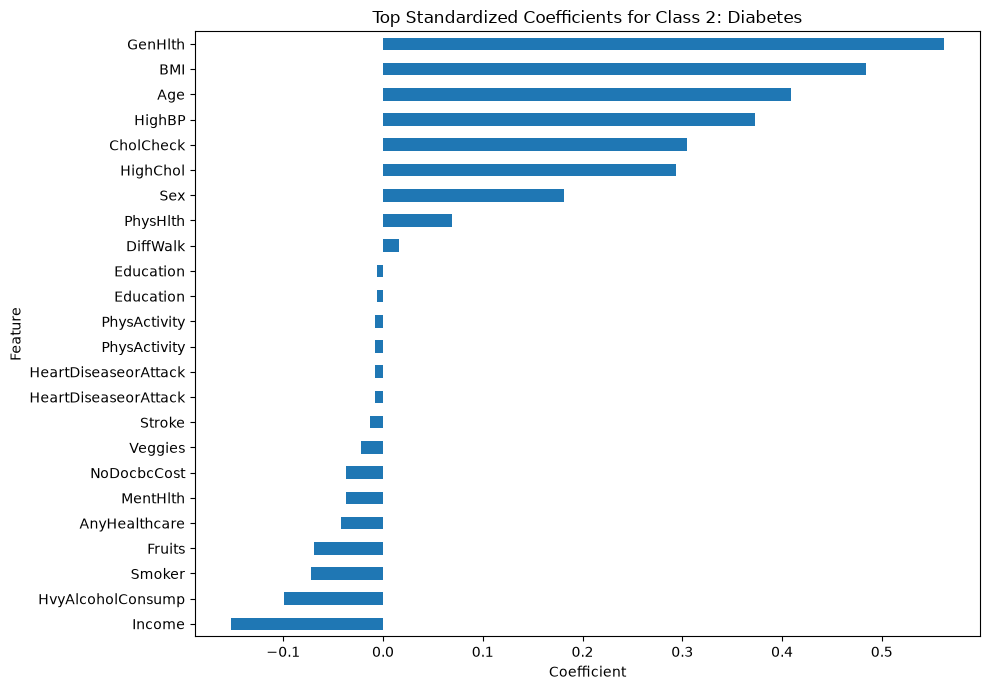

In [67]:
top_diabetes_coefficients = pd.concat([
    top_negative_diabetes,
    top_positive_diabetes
]).sort_values()

top_diabetes_coefficients.plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Top Standardized Coefficients for Class 2: Diabetes")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

- The coefficient plot shows which **standardized predictors** push the model toward or away from predicting class 2 diabetes.

    - **Positive coefficients** push the model **toward diabetes**
    
    - **Negative coefficients** push the model away from diabetes 

- The strongest positive predictors were **general health**, **BMI**, **age**, **high blood pressure**, and **high cholesterol**

- This is one of the major advantages of scaled logistic regression: coefficient magnitudes become more comparable across features

#### [Dataset 1] | *13- Classification report for best scaled model*

In [68]:
best_scaled_model_name = scaling_results_df.loc[
    scaling_results_df["Macro F1"].idxmax(),
    "Model"
]

best_scaled_predictions = scaling_predictions[best_scaled_model_name]

print("Best scaled model by Macro F1:", best_scaled_model_name)

print(classification_report(
    y_test,
    best_scaled_predictions,
    digits=3,
    zero_division=0
))

best_scaled_confusion = pd.DataFrame(
    confusion_matrix(y_test, best_scaled_predictions),
    index=["Actual 0", "Actual 1", "Actual 2"],
    columns=["Predicted 0", "Predicted 1", "Predicted 2"]
)

display(best_scaled_confusion)

Best scaled model by Macro F1: Normalization
              precision    recall  f1-score   support

           0      0.898     0.892     0.895     42741
           1      0.047     0.064     0.054       926
           2      0.419     0.416     0.417      7069

    accuracy                          0.811     50736
   macro avg      0.455     0.457     0.455     50736
weighted avg      0.815     0.811     0.813     50736



,Predicted 0,Predicted 1,Predicted 2
Actual 0,38130,783,3828
Actual 1,620,59,247
Actual 2,3724,407,2938


- The best scaled model by **macro F1** was the **normalization model**

- The **classification report** was:

| Class | Precision | Recall | F1-score | Support |
|---:|---:|---:|---:|---:|
| 0 | 0.898 | 0.892 | 0.895 | 42,741 |
| 1 | 0.047 | 0.064 | 0.054 | 926 |
| 2 | 0.419 | 0.416 | 0.417 | 7,069 |

- **Overall results**:

| Metric | Value |
|---|---:|
| Accuracy | 0.811 |
| Macro F1 | 0.455 |
| Weighted F1 | 0.813 |

The **confusion matrix** was:

|  | Predicted 0 | Predicted 1 | Predicted 2 |
|---|---:|---:|---:|
| Actual 0 | 38,130 | 783 | 3,828 |
| Actual 1 | 620 | 59 | 247 |
| Actual 2 | 3,724 | 407 | 2,938 |


- The model performed well on **class 0** but struggled with **class 1**, **prediabetes**

    - It correctly identified only **59** of the **926** prediabetes cases
    
    - This is expected because class 1 is very **rare** and **overlaps** with the other classes

- For this dataset, **feature scaling** improved **optimization speed** and **slightly improved macro-level performance**, but it **did not** fully solve the class **imbalance** problem

#### [Dataset 1] | *14- Summary*

- The **most important result** is that scaling strongly improved optimization efficiency

    - The **no-scaling model** required **264 iterations and about 20.4 seconds**, while **normalization** required only **25 iterations and about 2.0 seconds**

- By **macro F1**, **normalization** was the best scaling method

- By **regularization** comparison, **L2 logistic regression** performed best after **standardization**, while **L1 and Elastic Net** removed some features

- The **main takeaway** is that logistic regression is appropriate for categorical outcomes, and feature scaling is especially important when using gradient-based optimization or regularization

## Dataset 2: Obesity Levels

#### [Dataset 2] | *1- Load preprocessed obesity dataset*

In [69]:
obesity_path = "obesity_preprocessed_wk1.csv"


df_obesity_model = pd.read_csv(obesity_path)

print("Dataset shape:", df_obesity_model.shape)
display(df_obesity_model.head())

target = "NObeyesdad"

class_counts = df_obesity_model[target].value_counts()
class_percent = (class_counts / len(df_obesity_model) * 100).round(2)

class_summary = pd.DataFrame({
    "Class Count": class_counts.astype(int),
    "Percent": class_percent
})

display(class_summary)

Dataset shape: (2111, 24)


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,family_history_with_overweight_yes,...,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,NObeyesdad
0,21.0,1.62,64.0,2.0,3.0,2.0,0.0,1.0,0,1,...,0,0,0,0,1,0,0,1,0,Normal_Weight
1,21.0,1.52,56.0,3.0,3.0,3.0,3.0,0.0,0,1,...,1,1,0,1,0,0,0,1,0,Normal_Weight
2,23.0,1.80,77.0,2.0,3.0,2.0,2.0,1.0,1,1,...,0,0,1,0,0,0,0,1,0,Normal_Weight
3,27.0,1.80,87.0,3.0,3.0,2.0,2.0,0.0,1,0,...,0,0,1,0,0,0,0,0,1,Overweight_Level_I
4,22.0,1.78,89.8,2.0,1.0,2.0,0.0,0.0,1,0,...,0,0,0,1,0,0,0,1,0,Overweight_Level_II


,Class Count,Percent
NObeyesdad,,
Obesity_Type_I,351,16.63
Obesity_Type_III,324,15.35
Obesity_Type_II,297,14.07
Overweight_Level_I,290,13.74
Overweight_Level_II,290,13.74
Normal_Weight,287,13.60
Insufficient_Weight,272,12.88


- The obesity dataset shape was:

| Rows | Columns |
|---:|---:|
| 2,111 | 24 |

- There are **23 predictor columns** and one target column, `NObeyesdad`

- The class distribution was:

| Class | Class Count | Percent |
|---|---:|---:|
| Obesity_Type_I | 351 | 16.63 |
| Obesity_Type_III | 324 | 15.35 |
| Obesity_Type_II | 297 | 14.07 |
| Overweight_Level_I | 290 | 13.74 |
| Overweight_Level_II | 290 | 13.74 |
| Normal_Weight | 287 | 13.60 |
| Insufficient_Weight | 272 | 12.88 |

- The classes are fairly **balanced** compared with the diabetes dataset. Accuracy is useful here, but macro F1 and balanced accuracy are still important because this is a **multiclass classification** problem

#### [Dataset 2] | *2- Train-test split*

In [70]:
X = df_obesity_model.drop(columns=[target])
y = df_obesity_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

display(y_train.value_counts().to_frame("Train Class Count"))
display(y_test.value_counts().to_frame("Test Class Count"))

Training shape: (1688, 23)
Testing shape: (423, 23)


,Train Class Count
NObeyesdad,
Obesity_Type_I,281
Obesity_Type_III,259
Obesity_Type_II,237
Overweight_Level_I,232
Overweight_Level_II,232
Normal_Weight,229
Insufficient_Weight,218


,Test Class Count
NObeyesdad,
Obesity_Type_I,70
Obesity_Type_III,65
Obesity_Type_II,60
Normal_Weight,58
Overweight_Level_II,58
Overweight_Level_I,58
Insufficient_Weight,54


- The data was split into **training and testing** sets using **stratification**

- The split was:

| Split | Shape |
|---|---:|
| Training | (1,688, 23) |
| Testing | (423, 23) |

- **Stratification** keeps the obesity-class **proportions similar** in both the training and test sets. This matters because the model should be evaluated fairly across all seven obesity categories.

#### [Dataset 2] | *3- Investigate feature scales*

In [71]:
scale_summary = pd.DataFrame({
    "Feature": X.columns,
    "Minimum": X.min().values,
    "Maximum": X.max().values,
    "Mean": X.mean().values,
    "Std": X.std().values
})

scale_summary["Range"] = scale_summary["Maximum"] - scale_summary["Minimum"]

display(
    scale_summary
    .sort_values("Range", ascending=False)
    .head(10)
)

,Feature,Minimum,Maximum,Mean,Std,Range
2,Weight,39.0,173.0,86.586058,26.191172,134.0
0,Age,14.0,61.0,24.312600,6.345968,47.0
4,NCP,1.0,4.0,2.685628,0.778039,3.0
6,FAF,0.0,3.0,1.010298,0.850592,3.0
3,FCVC,1.0,3.0,2.419043,0.533927,2.0
5,CH2O,1.0,3.0,2.008011,0.612953,2.0
7,TUE,0.0,2.0,0.657866,0.608927,2.0
15,SCC_yes,0.0,1.0,0.045476,0.208395,1.0
8,Gender_Male,0.0,1.0,0.505921,0.500083,1.0
9,family_history_with_overweight_yes,0.0,1.0,0.817622,0.386247,1.0



- This confirms why **feature scaling matters**

    -  `Weight` has a much larger range than binary variables such as `Gender_Male`, `SCC_yes`, or `FAVC_yes`. 
    
    - Without scaling, **gradient-based logistic regression** can be strongly affected by variables measured on larger numeric scales.

#### [Dataset 2] | *4- Visualize feature ranges*

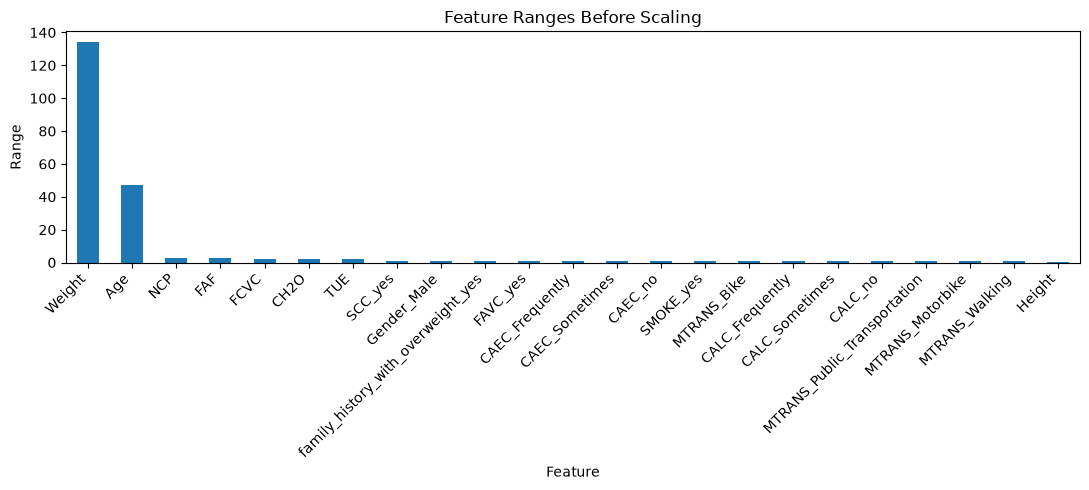

In [72]:
scale_summary.sort_values("Range", ascending=False).plot(
    x="Feature",
    y="Range",
    kind="bar",
    figsize=(11, 5),
    legend=False
)

plt.title("Feature Ranges Before Scaling")
plt.xlabel("Feature")
plt.ylabel("Range")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

- The **feature-range plot** visually confirms that the predictors are not on the same scale

- `Weight` has the largest range by far, followed by `Age`. 

- Many one-hot encoded categorical variables have a range of only 1

- This supports the Week 4 idea that scaling is important before logistic regression, especially when using gradient descent

#### [Dataset 2] | *5- Define model evaluation function*

In [73]:
def evaluate_logistic_model(model_name, model):
    start_time = time.time()
    
    model.fit(X_train, y_train)
    
    fit_time = time.time() - start_time
    
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)
    
    classes = model.named_steps["sgd_logit"].classes_
    
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_test, predictions),
        "Macro F1": f1_score(y_test, predictions, average="macro"),
        "Weighted F1": f1_score(y_test, predictions, average="weighted"),
        "Macro OVR ROC AUC": roc_auc_score(
            y_test,
            probabilities,
            multi_class="ovr",
            average="macro",
            labels=classes
        ),
        "Log Loss": log_loss(
            y_test,
            probabilities,
            labels=classes
        ),
        "Iterations": int(model.named_steps["sgd_logit"].n_iter_),
        "Fit Time Seconds": fit_time
    }
    
    return metrics, predictions, probabilities, model

- This **helper function** trains a **logistic regression model, generates predictions, and calculates evaluation metrics**

- The most important **metrics** here are:

    - `Log Loss`, which is connected to cross-entropy loss.
    - `Iterations`, which helps show whether scaling improves optimization.
    - `Fit Time Seconds`, which helps compare training speed.

- **Accuracy, balanced accuracy, macro F1, weighted F1, and ROC AUC** are also included because this is a **multiclass** classification problem.

#### [Dataset 2] | *6- Compare no scaling, standardization, and normalization*

In [74]:
scaling_models = {
    "No scaling": Pipeline(
        steps=[
            ("sgd_logit", SGDClassifier(
                loss="log_loss",
                penalty="l2",
                alpha=0.0001,
                class_weight="balanced",
                max_iter=1000,
                tol=1e-3,
                random_state=42
            ))
        ]
    ),
    "Standardization": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("sgd_logit", SGDClassifier(
                loss="log_loss",
                penalty="l2",
                alpha=0.0001,
                class_weight="balanced",
                max_iter=1000,
                tol=1e-3,
                random_state=42
            ))
        ]
    ),
    "Normalization": Pipeline(
        steps=[
            ("scaler", MinMaxScaler()),
            ("sgd_logit", SGDClassifier(
                loss="log_loss",
                penalty="l2",
                alpha=0.0001,
                class_weight="balanced",
                max_iter=1000,
                tol=1e-3,
                random_state=42
            ))
        ]
    )
}

scaling_results = []
scaling_predictions = {}
scaling_probabilities = {}
scaling_fitted_models = {}

for model_name, model in scaling_models.items():
    metrics, predictions, probabilities, fitted_model = evaluate_logistic_model(
        model_name,
        model
    )
    
    scaling_results.append(metrics)
    scaling_predictions[model_name] = predictions
    scaling_probabilities[model_name] = probabilities
    scaling_fitted_models[model_name] = fitted_model

scaling_results_df = pd.DataFrame(scaling_results)

display(scaling_results_df)

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro OVR ROC AUC,Log Loss,Iterations,Fit Time Seconds
0,No scaling,0.420804,0.430952,0.285396,0.277664,0.861371,20.037935,114,0.065472
1,Standardization,0.704492,0.701228,0.707318,0.708902,0.912134,1.230935,97,0.053674
2,Normalization,0.669031,0.672141,0.654039,0.653284,0.918083,0.968069,57,0.036495


- The **scaling comparison** was:

| Model | Accuracy | Balanced Accuracy | Macro F1 | Weighted F1 | Macro OVR ROC AUC | Log Loss | Iterations | Fit Time Seconds |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| **No scaling** | 0.420804	 | 0.430952 | 0.285396 | 0.277664	 | 0.861371 | 	20.037935 | 114 | 0.065617 |
| **Standardization** | 0.704492 | 0.701228 | 0.707318 | 0.708902 | 0.911730 | 1.234266 | 97 |0.053988 |
| **Normalization** | 0.669031 | 0.672141 | 0.654039 | 0.653284 | 0.918083 | 0.968069 | 57 | 0.037302 |

- The best model by **macro F1** was **standardization**, with **macro F1 = 0.707318**

- The **no-scaling** model performed much worse, especially on **macro F1** and **log loss**

    - Its **log loss was extremely high**, which means the predicted probabilities were poorly calibrated or overly confident in wrong predictions.

- **Normalization** had the best **ROC AUC** and **lowest log loss**, and it also required the fewest **iterations**

#### [Dataset 2] | *7- Visualize scaling comparison*

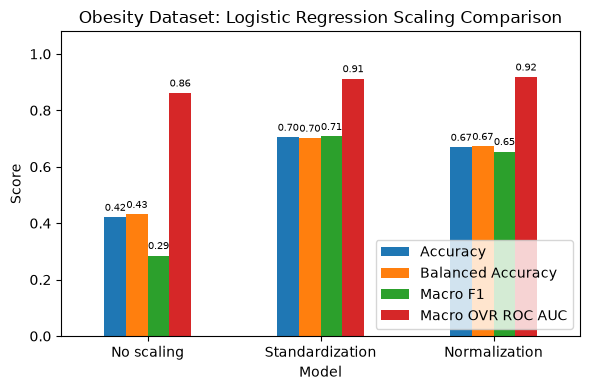

In [85]:
ax = scaling_results_df.set_index("Model")[
    ["Accuracy", "Balanced Accuracy", "Macro F1", "Macro OVR ROC AUC"]
].plot(
    kind="bar",
    figsize=(6, 4)
)

# Add bar values
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=7
    )

plt.title("Obesity Dataset: Logistic Regression Scaling Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0, ha="center")

# Slightly above 1 so the labels are visible
plt.ylim(0, 1.08)

plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

- The **scaling comparison plot** shows that **scaling clearly improves model performance**

- The **no-scaling** model performs poorly compared with both scaling methods. 

- **Standardization** gives the best **accuracy**, **balanced accuracy**, and **macro F1**

- **Normalization** gives the strongest **ROC AUC**

- This means both scaling methods are useful, but **standardization** is better for direct class prediction in this execution

#### [Dataset 2] | *8- Visualize optimization speed*

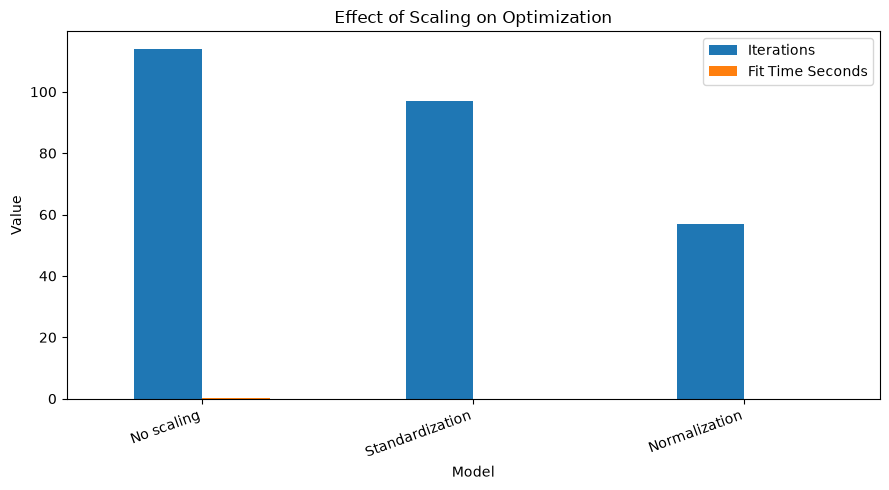

In [22]:
scaling_results_df.set_index("Model")[
    ["Iterations", "Fit Time Seconds"]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Effect of Scaling on Optimization")
plt.ylabel("Value")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

- This plot shows the **optimization effect of scaling**

- The **no-scaling** model required **101** iterations. The **standardized** model required **97** iterations, while the **normalized** model required only **57** iterations.

- **Fit time** was also lowest for normalization

- This supports the Week 4 explanation that scaling can help gradient-based algorithms train more efficiently

#### [Dataset 2] | *9- Compare L1, L2, and Elastic Net logistic regression after standardization*

In [23]:
regularized_models = {
    "L1 logistic regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("sgd_logit", SGDClassifier(
                loss="log_loss",
                penalty="l1",
                alpha=0.0001,
                class_weight="balanced",
                max_iter=1000,
                tol=1e-3,
                random_state=42
            ))
        ]
    ),
    "L2 logistic regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("sgd_logit", SGDClassifier(
                loss="log_loss",
                penalty="l2",
                alpha=0.0001,
                class_weight="balanced",
                max_iter=1000,
                tol=1e-3,
                random_state=42
            ))
        ]
    ),
    "Elastic-net logistic regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("sgd_logit", SGDClassifier(
                loss="log_loss",
                penalty="elasticnet",
                l1_ratio=0.5,
                alpha=0.0001,
                class_weight="balanced",
                max_iter=1000,
                tol=1e-3,
                random_state=42
            ))
        ]
    )
}

regularized_results = []
regularized_predictions = {}
regularized_probabilities = {}
regularized_fitted_models = {}

for model_name, model in regularized_models.items():
    metrics, predictions, probabilities, fitted_model = evaluate_logistic_model(
        model_name,
        model
    )
    
    coefficients = fitted_model.named_steps["sgd_logit"].coef_
    active_mask = np.any(np.abs(coefficients) > 1e-8, axis=0)
    
    metrics["Active Features"] = int(active_mask.sum())
    metrics["Zeroed Features"] = int(X.shape[1] - active_mask.sum())
    
    regularized_results.append(metrics)
    regularized_predictions[model_name] = predictions
    regularized_probabilities[model_name] = probabilities
    regularized_fitted_models[model_name] = fitted_model

regularized_results_df = pd.DataFrame(regularized_results)

display(regularized_results_df)

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro OVR ROC AUC,Log Loss,Iterations,Fit Time Seconds,Active Features,Zeroed Features
0,L1 logistic regression,0.737589,0.737328,0.739087,0.738836,0.903354,1.343734,52,0.054479,23,0
1,L2 logistic regression,0.704492,0.701228,0.707318,0.708902,0.912134,1.230935,97,0.054970,23,0
2,Elastic-net logistic regression,0.721040,0.718810,0.725666,0.726018,0.918920,1.263961,97,0.080920,23,0


- The **regularization** comparison **after standardization** was:

| Model | Accuracy | Balanced Accuracy | Macro F1 | Weighted F1 | Macro OVR ROC AUC | Log Loss | Iterations | Active Features | Zeroed Features |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| **L1 logistic regression** | 0.735225 | 0.734865 | 0.735929 | 0.736181 | 0.900549 | 1.333177 | 52 | 23 | 0 |
| **L2 logistic regression** | 0.704492 | 0.701228 | 0.707318 | 0.708902 | 0.911730 | 1.234266 | 97 | 23 | 0 |
| **Elastic-net logistic regression** | 0.721040 | 0.718810 | 0.725666 | 0.726018 | 0.918999 | 1.262521 | 97 | 23 | 0 |


- The best model by **macro F1** was **L1 logistic regression**, with macro **F1 = 0.74**

- Interestingly, **L1** did not zero out any features in this execution

    - That means the **regularization strength** was not strong enough to remove predictors, even though **L1** is capable of feature selection. 
    
    - However, it still produced the best direct classification performance.

- **Elastic Net** had the best **ROC AUC**, while **L2** had lower **macro F1** than **L1** and **Elastic Net**.

#### [Dataset 2] | *10- Visualize regularization comparison*

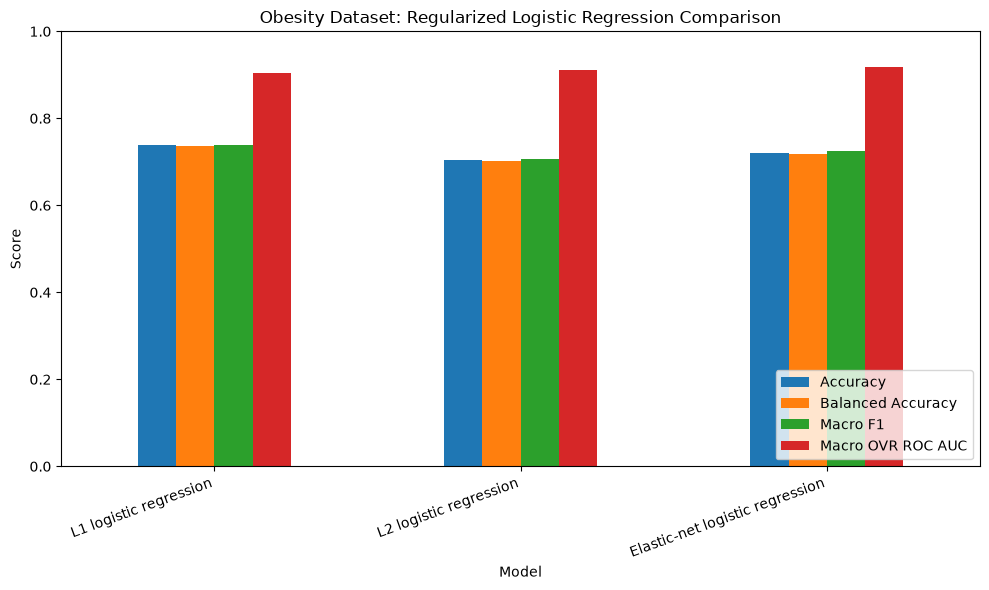

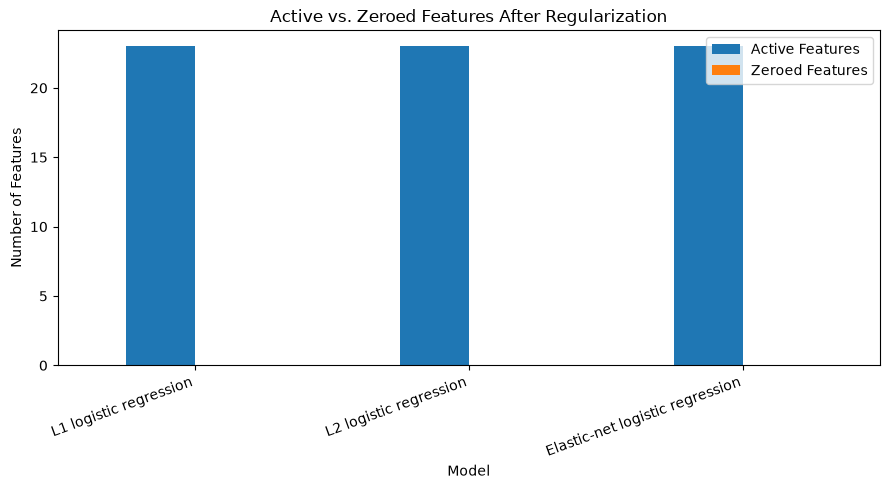

In [24]:
regularized_results_df.set_index("Model")[
    ["Accuracy", "Balanced Accuracy", "Macro F1", "Macro OVR ROC AUC"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Obesity Dataset: Regularized Logistic Regression Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

regularized_results_df.set_index("Model")[
    ["Active Features", "Zeroed Features"]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Active vs. Zeroed Features After Regularization")
plt.ylabel("Number of Features")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

- The first plot compares L**1, L2, and Elastic-net logistic regression**:

    - **L1** performed best by 
        - accuracy
        - balanced accuracy
        - macro F1
        - weighted F1
    
    - **Elastic Net** had the highest ROC AUC

- The second plot shows that all **23 predictors stayed active** for all three models.

- This means regularization affected **coefficient sizes and optimization**, but it did not perform **feature removal** in this execution.

#### [Dataset 2] | *11- Inspect standardized logistic regression coefficients*

In [25]:
standardized_model = scaling_fitted_models["Standardization"]

coef_df = pd.DataFrame(
    standardized_model.named_steps["sgd_logit"].coef_,
    index=standardized_model.named_steps["sgd_logit"].classes_,
    columns=X.columns
)

selected_class = "Obesity_Type_III"

top_positive_obesity = (
    coef_df
    .loc[selected_class]
    .sort_values(ascending=False)
    .head(12)
)

top_negative_obesity = (
    coef_df
    .loc[selected_class]
    .sort_values(ascending=True)
    .head(12)
)

print(f"Top positive coefficients for {selected_class}")
display(top_positive_obesity)

print(f"Top negative coefficients for {selected_class}")
display(top_negative_obesity)

Top positive coefficients for Obesity_Type_III


Weight                                16.789683
FCVC                                  16.607454
family_history_with_overweight_yes     7.153650
CAEC_Sometimes                         6.661241
NCP                                    6.545504
CALC_Sometimes                         4.057311
MTRANS_Public_Transportation           2.022403
TUE                                    0.366741
CH2O                                  -0.222064
SMOKE_yes                             -0.483554
Age                                   -0.500800
MTRANS_Bike                           -0.643176
Name: Obesity_Type_III, dtype: float64

Top negative coefficients for Obesity_Type_III


Gender_Male        -15.723567
FAF                 -8.379858
CAEC_Frequently     -5.290790
FAVC_yes            -3.676904
SCC_yes             -3.596850
CALC_Frequently     -3.332620
MTRANS_Walking      -3.239148
CAEC_no             -3.193880
CALC_no             -2.868567
Height              -2.824093
MTRANS_Motorbike    -0.761469
MTRANS_Bike         -0.643176
Name: Obesity_Type_III, dtype: float64

- Using the **standardized logistic regression model**, the **strongest positive coefficients** for `Obesity_Type_III` were:

| Feature | Coefficient |
|---|---:|
| Weight | 16.789683 |
| FCVC | 16.607454 |
| family_history_with_overweight_yes | 7.153650 |
| CAEC_Sometimes | 6.661241 |
| NCP | 6.545504 |
| CALC_Sometimes | 4.057311 |
| MTRANS_Public_Transportation | 2.022403 |
| TUE | 0.366741 |
| CH2O | -0.222064 |
| SMOKE_yes | -0.483554 |
| Age | -0.500800 |
| MTRANS_Bike | -0.643176 |

The **strongest negative coefficients** were:

| Feature | Coefficient |
|---|---:|
| Gender_Male | -15.723567 |
| FAF | -8.379858 |
| CAEC_Frequently | -5.290790 |
| FAVC_yes | -3.676904 |
| SCC_yes | -3.596850 |
| CALC_Frequently | -3.332620 |
| MTRANS_Walking | -3.239148 |
| CAEC_no | -3.193880 |
| CALC_no | -2.868567 |
| Height | -2.824093 |
| MTRANS_Motorbike | -0.761469 |
| MTRANS_Bike | -0.643176 |

- The **strongest positive** predictor for `Obesity_Type_III` was `Weight`, which makes sense because higher body weight strongly separates the highest obesity class. 

- `FCVC`, family history, and eating-behavior variables also contributed positively.

- The **negative coefficients** indicate variables that push the model away from predicting `Obesity_Type_III`. 


- **NOTE:** These are predictive relationships, not causal claims.

#### [Dataset 2] | *12- Visualize top coefficients for Obesity Type III*

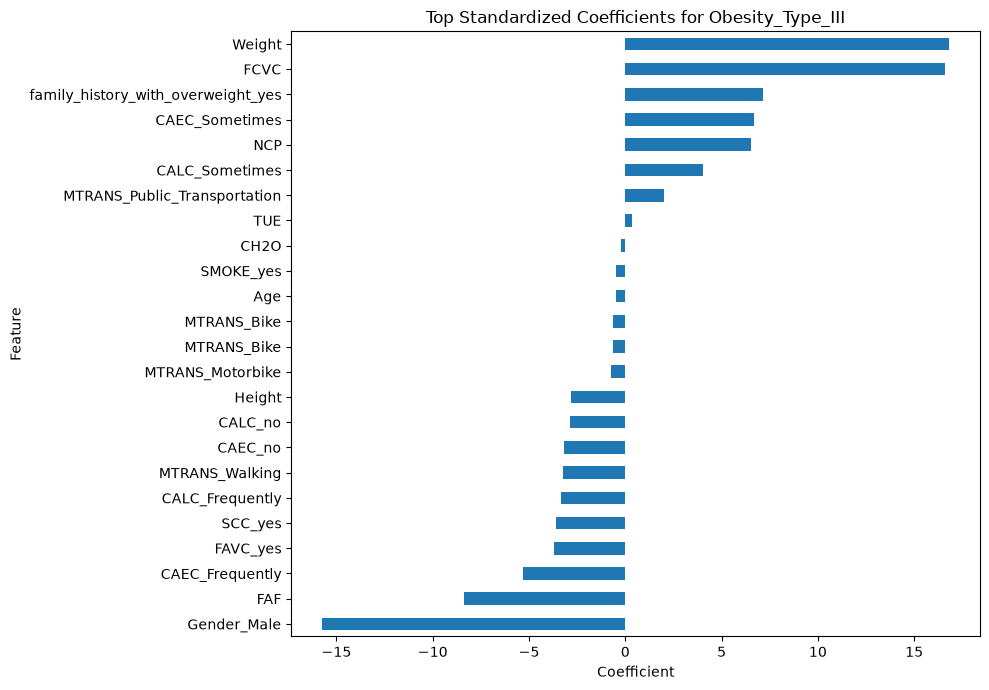

In [26]:
top_obesity_coefficients = pd.concat([
    top_negative_obesity,
    top_positive_obesity
]).sort_values()

top_obesity_coefficients.plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Top Standardized Coefficients for Obesity_Type_III")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

- The **coefficient plot** shows which standardized predictors push the model toward or away from predicting `Obesity_Type_III`

- **Positive coefficients** push the model toward `Obesity_Type_III`, while n**egative coefficients** push it away

- Because the model uses **standardization**, the coefficients are more comparable across predictors than they would be on the raw scale

#### [Dataset 2] | *13- Classification report for best scaled model*

In [27]:
best_scaled_model_name = scaling_results_df.loc[
    scaling_results_df["Macro F1"].idxmax(),
    "Model"
]

best_scaled_predictions = scaling_predictions[best_scaled_model_name]

print("Best scaled model by Macro F1:", best_scaled_model_name)

print(classification_report(
    y_test,
    best_scaled_predictions,
    digits=3,
    zero_division=0
))

labels = list(
    scaling_fitted_models[best_scaled_model_name]
    .named_steps["sgd_logit"]
    .classes_
)

best_scaled_confusion = pd.DataFrame(
    confusion_matrix(y_test, best_scaled_predictions, labels=labels),
    index=[f"Actual {label}" for label in labels],
    columns=[f"Predicted {label}" for label in labels]
)

display(best_scaled_confusion)

Best scaled model by Macro F1: Standardization
                     precision    recall  f1-score   support

Insufficient_Weight      0.979     0.870     0.922        54
      Normal_Weight      0.623     0.569     0.595        58
     Obesity_Type_I      0.595     0.671     0.631        70
    Obesity_Type_II      0.948     0.917     0.932        60
   Obesity_Type_III      1.000     0.985     0.992        65
 Overweight_Level_I      0.481     0.431     0.455        58
Overweight_Level_II      0.391     0.466     0.425        58

           accuracy                          0.704       423
          macro avg      0.717     0.701     0.707       423
       weighted avg      0.717     0.704     0.709       423



,Predicted Insufficient_Weight,Predicted Normal_Weight,Predicted Obesity_Type_I,Predicted Obesity_Type_II,Predicted Obesity_Type_III,Predicted Overweight_Level_I,Predicted Overweight_Level_II
Actual Insufficient_Weight,47,5,0,0,0,2,0
Actual Normal_Weight,1,33,2,0,0,9,13
Actual Obesity_Type_I,0,1,47,1,0,7,14
Actual Obesity_Type_II,0,2,1,55,0,1,1
Actual Obesity_Type_III,0,0,0,1,64,0,0
Actual Overweight_Level_I,0,8,11,0,0,25,14
Actual Overweight_Level_II,0,4,18,1,0,8,27


- The **best scaled model** by **macro F1** was the **standardization model**.

- The classification report was:

| Class | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| Insufficient_Weight | 0.979 | 0.870 | 0.922 | 54 |
| Normal_Weight | 0.623 | 0.569 | 0.595 | 58 |
| Obesity_Type_I | 0.595 | 0.671 | 0.631 | 70 |
| Obesity_Type_II | 0.948 | 0.917 | 0.932 | 60 |
| Obesity_Type_III | 1.000 | 0.985 | 0.992 | 65 |
| Overweight_Level_I | 0.481 | 0.431 | 0.455 | 58 |
| Overweight_Level_II | 0.391 | 0.466 | 0.425 | 58 |

- Overall results:

| Metric | Value |
|---|---:|
| Accuracy | 0.704 |
| Macro F1 | 0.707 |
| Weighted F1 | 0.709 |

- The **confusion matrix** showed that the model performed very well on `Obesity_Type_III`, `Obesity_Type_II`, and `Insufficient_Weight`. 
    - The weakest classes were `Overweight_Level_I` and `Overweight_Level_II`.

- Most errors happened between neighboring weight categories, which is expected because adjacent obesity levels are naturally more similar than extreme categories.

#### [Dataset 2] | *14- Summary*

- The main result is that s**caling strongly improved logistic regression performance**. 

    - The **no-scaling model had macro F1 of only 0.340061**, while **standardization improved macro F1 to 0.707318**. 
    
    - **Normalization** produced the **best ROC AUC and lowest log loss**, but **standardization gave the best direct class-prediction performance**.

- For **regularized logistic regression**, **L1** produced the best m**acro F1**, while **Elastic Net** produced the **best ROC AUC**. 

- However, **none of the regularized models** removed predictors in this execution.

- The **main takeaway** is that **logistic regression is appropriate for this categorical target**, and f**eature scaling is very important when using gradient-based logistic regression**.

## Dataset 3: Cervical Cancer

#### [Dataset 3] | *1- Load preprocessed cervical cancer dataset*

In [29]:
cervical_path = "cervical_cancer_preprocessed_wk1.csv"

df_cervical_model = pd.read_csv(cervical_path)

print("Dataset shape:", df_cervical_model.shape)
display(df_cervical_model.head())

target = "Biopsy"

class_counts = df_cervical_model[target].value_counts().sort_index()
class_percent = (class_counts / len(df_cervical_model) * 100).round(2)

class_summary = pd.DataFrame({
    "Class Count": class_counts.astype(int),
    "Percent": class_percent
})

display(class_summary)

Dataset shape: (858, 62)


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs:pelvic inflammatory disease_missing,STDs:genital herpes_missing,STDs:molluscum contagiosum_missing,STDs:AIDS_missing,STDs:HIV_missing,STDs:Hepatitis B_missing,STDs:HPV_missing,STDs: Time since first diagnosis_missing,STDs: Time since last diagnosis_missing,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,1,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,1,0
2,34,1.0,17.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,1,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,0,0,0,0,0,0,0,1,1,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,0,0,0,0,0,0,0,1,1,0


,Class Count,Percent
Biopsy,,
0,803,93.59
1,55,6.41


- This is a **highly imbalanced binary classification problem**
    - Only **55** observations are biopsy-positive
    - Therefore, accuracy alone is not enough. Balanced accuracy, recall, F1, ROC AUC, and average precision are more useful for evaluating model performance

#### [Dataset 3] | *2- Train-test split*

In [30]:
X = df_cervical_model.drop(columns=[target])
y = df_cervical_model[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

display(y_train.value_counts().sort_index().to_frame("Train Class Count"))
display(y_test.value_counts().sort_index().to_frame("Test Class Count"))

Training shape: (686, 61)
Testing shape: (172, 61)


,Train Class Count
Biopsy,
0,642
1,44


,Test Class Count
Biopsy,
0,161
1,11


- The data was **split** into training and testing sets using **stratification**

- The executed split was:

| Split | Shape |
|---|---:|
| Training | (686, 61) |
| Testing | (172, 61) |

- The **training target distribution** was:

| Class | Count |
|---:|---:|
| 0 | 642 |
| 1 | 44 |

- The **testing target distribution** was:

| Class | Count |
|---:|---:|
| 0 | 161 |
| 1 | 11 |

- **Stratification** is important because the **positive biopsy class is rare**
    - It keeps the **minority class represented** in both the training and test sets.

#### [Dataset 3] | *3- Investigate feature scales*

In [31]:
scale_summary = pd.DataFrame({
    "Feature": X.columns,
    "Minimum": X.min().values,
    "Maximum": X.max().values,
    "Mean": X.mean().values,
    "Std": X.std().values
})

scale_summary["Range"] = scale_summary["Maximum"] - scale_summary["Minimum"]

display(
    scale_summary
    .sort_values("Range", ascending=False)
    .head(12)
)

,Feature,Minimum,Maximum,Mean,Std,Range
0,Age,13.0,84.0,26.820513,8.497948,71.0
6,Smokes (packs/year),0.0,37.0,0.446278,2.210351,37.0
5,Smokes (years),0.0,37.0,1.201241,4.060623,37.0
8,Hormonal Contraceptives (years),0.0,30.0,2.035331,3.567040,30.0
1,Number of sexual partners,1.0,28.0,2.511655,1.644759,27.0
2,First sexual intercourse,10.0,32.0,16.995338,2.791883,22.0
26,STDs: Time since first diagnosis,1.0,22.0,4.177156,1.785156,21.0
27,STDs: Time since last diagnosis,1.0,22.0,3.233100,1.818927,21.0
10,IUD (years),0.0,19.0,0.444604,1.814218,19.0
3,Num of pregnancies,0.0,11.0,2.257576,1.400981,11.0


- The **feature-scale summary** showed that the largest feature ranges were:

| Feature | Minimum | Maximum | Mean | Std | Range |
|---|---:|---:|---:|---:|---:|
| Age | 13.0 | 84.0 | 26.821 | 8.498 | 71.0 |
| Smokes (packs/year) | 0.0 | 37.0 | 0.446 | 2.210 | 37.0 |
| Smokes (years) | 0.0 | 37.0 | 1.201 | 4.061 | 37.0 |
| Hormonal Contraceptives (years) | 0.0 | 30.0 | 2.035 | 3.567 | 30.0 |
| Number of sexual partners | 1.0 | 28.0 | 2.512 | 1.645 | 27.0 |
| First sexual intercourse | 10.0 | 32.0 | 16.995 | 2.792 | 22.0 |
| STDs: Time since first diagnosis | 1.0 | 22.0 | 4.177 | 1.785 | 21.0 |
| STDs: Time since last diagnosis | 1.0 | 22.0 | 3.233 | 1.819 | 21.0 |
| IUD (years) | 0.0 | 19.0 | 0.445 | 1.814 | 19.0 |
| Num of pregnancies | 0.0 | 11.0 | 2.258 | 1.401 | 11.0 |

- The **predictors** are clearly on different scales: 

    - Some variables, such as `Age`, `Smokes (years)`, and `Hormonal Contraceptives (years)`, have much larger numeric ranges than binary variables such as `Schiller`, `Hinselmann`, or missingness indicators.

- This supports the Week 4 point that **feature scaling matters before gradient-based logistic regression**

#### [Dataset 3] | *4- Visualize feature ranges*

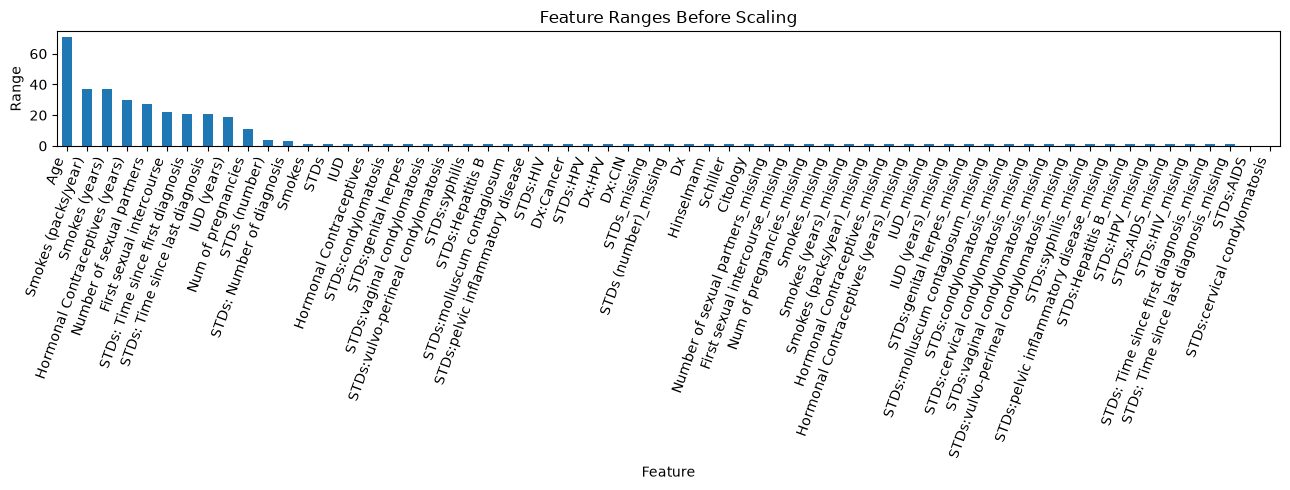

In [32]:
scale_summary.sort_values("Range", ascending=False).plot(
    x="Feature",
    y="Range",
    kind="bar",
    figsize=(13, 5),
    legend=False
)

plt.title("Feature Ranges Before Scaling")
plt.xlabel("Feature")
plt.ylabel("Range")
plt.xticks(rotation=70, ha="right")
plt.tight_layout()
plt.show()

- The **feature-range plot** visually confirms that the predictors are not on the same scale

- `Age` has the largest range, followed by **smoking-related**and **contraception-related** variables

- Many **diagnostic** or **binary** variables have a range of only 1

- This is exactly the situation where **scaling can help logistic regression train more consistently**

#### [Dataset 3] | *5- Define model evaluation function*

In [33]:
def evaluate_logistic_model(model_name, model):
    start_time = time.time()
    
    model.fit(X_train, y_train)
    
    fit_time = time.time() - start_time
    
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)
    
    classes = model.named_steps["sgd_logit"].classes_
    positive_index = list(classes).index(1)
    positive_probabilities = probabilities[:, positive_index]
    
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, positive_probabilities),
        "Average Precision": average_precision_score(y_test, positive_probabilities),
        "Log Loss": log_loss(
            y_test,
            probabilities,
            labels=classes
        ),
        "Iterations": int(model.named_steps["sgd_logit"].n_iter_),
        "Fit Time Seconds": fit_time
    }
    
    return metrics, predictions, probabilities, model

- This **helper function trains a logistic regression model, generates predictions, and calculates evaluation metrics**

- The most important **metrics** here are:

    - `Log Loss`, which is connected to cross-entropy loss.
    - `Iterations`, which helps show how scaling affects optimization.
    - `Fit Time Seconds`, which helps compare training speed.

- Because this is an **imbalanced binary classification task**, **precision, recall, F1, ROC AUC**, and **average precision** are also included.

#### [Dataset 3] | *6- Compare no scaling, standardization, and normalization*

In [34]:
scaling_models = {
    "No scaling": Pipeline(
        steps=[
            ("sgd_logit", SGDClassifier(
                loss="log_loss",
                penalty="l2",
                alpha=0.0001,
                class_weight="balanced",
                max_iter=1000,
                tol=1e-3,
                random_state=42
            ))
        ]
    ),
    "Standardization": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("sgd_logit", SGDClassifier(
                loss="log_loss",
                penalty="l2",
                alpha=0.0001,
                class_weight="balanced",
                max_iter=1000,
                tol=1e-3,
                random_state=42
            ))
        ]
    ),
    "Normalization": Pipeline(
        steps=[
            ("scaler", MinMaxScaler()),
            ("sgd_logit", SGDClassifier(
                loss="log_loss",
                penalty="l2",
                alpha=0.0001,
                class_weight="balanced",
                max_iter=1000,
                tol=1e-3,
                random_state=42
            ))
        ]
    )
}

scaling_results = []
scaling_predictions = {}
scaling_probabilities = {}
scaling_fitted_models = {}

for model_name, model in scaling_models.items():
    metrics, predictions, probabilities, fitted_model = evaluate_logistic_model(
        model_name,
        model
    )
    
    scaling_results.append(metrics)
    scaling_predictions[model_name] = predictions
    scaling_probabilities[model_name] = probabilities
    scaling_fitted_models[model_name] = fitted_model

scaling_results_df = pd.DataFrame(scaling_results)

display(scaling_results_df)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC AUC,Average Precision,Log Loss,Iterations,Fit Time Seconds
0,No scaling,0.941860,0.841897,0.533333,0.727273,0.615385,0.864483,0.504635,1.918616,47,0.005496
1,Standardization,0.953488,0.890457,0.600000,0.818182,0.692308,0.921231,0.587714,1.448053,35,0.005108
2,Normalization,0.953488,0.890457,0.600000,0.818182,0.692308,0.903444,0.563450,0.276458,54,0.006191


- The **scaling comparison** was:

| Model | Accuracy | Balanced Accuracy | Precision | Recall | F1 | ROC AUC | Average Precision | Log Loss | Iterations | Fit Time Seconds |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| No scaling | 0.941860 | 0.841897 | 0.533333 | 0.727273 | 0.615385 | 0.864483 | 0.504635 | 1.918616 | 47 |0.005496 |
| Standardization | 0.953488 | 0.890457 | 0.600000 | 0.818182 | 0.692308 | 0.921231 | 0.587714 | 1.448053 | 35 | 0.005108 |
| Normalization | 0.953488 | 0.890457 | 0.600000 | 0.818182 | 0.692308 | 0.903444 | 0.563450 | 0.276458 | 54 | 0.006191 |

- **Standardization** and **normalization** tied on **F1**, both reaching **0.692308**. 

- Both **scaled models** also improved **recall from 0.727273 to 0.818182**, meaning they identified **9 of the 11** biopsy-positive cases.

- **Standardization** had the best **ROC AUC** and **average precision**. 

- **Normalization** had the **lowest log loss**, which means its predicted probabilities were better calibrated for cross-entropy loss in this execution.

- Overall, **scaling** improved model performance compared with no scaling.

#### [Dataset 3] | *7- Visualize scaling comparison*

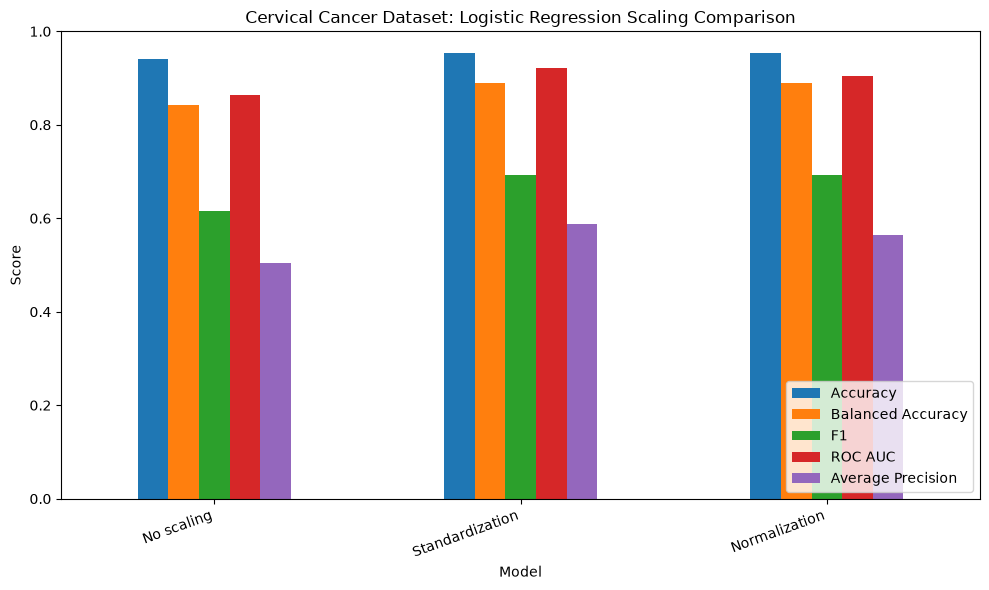

In [35]:
scaling_results_df.set_index("Model")[
    ["Accuracy", "Balanced Accuracy", "F1", "ROC AUC", "Average Precision"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Cervical Cancer Dataset: Logistic Regression Scaling Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

- The **scaling comparison plot** shows that **both standardization and normalization** improved performance compared with **no scaling**

    - **Standardization** produced the **strongest ROC AUC and average precision**. 
    
    - **Normalization** produced the **lowest log loss**, but it **did not improve F1** beyond **standardization**.

- For this dataset, **standardization** is the strongest overall scaling choice because it performs well across classification and ranking metrics

#### [Dataset 3] | *8- Visualize optimization speed*

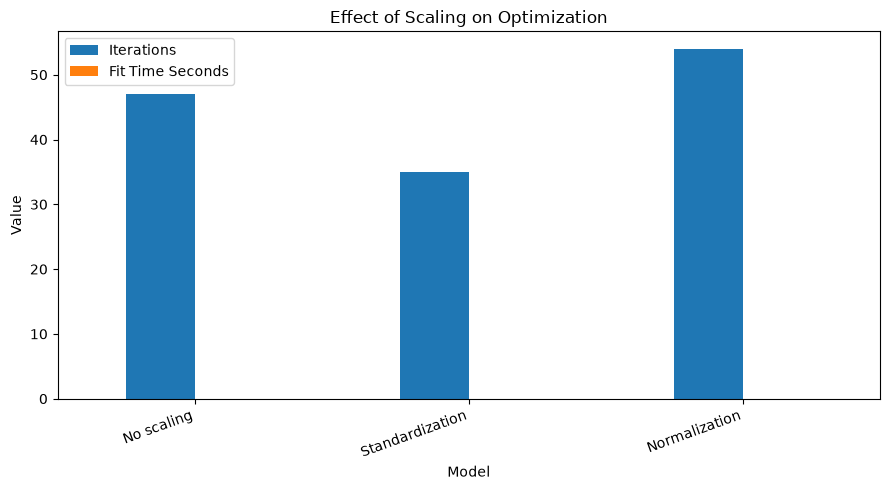

In [36]:
scaling_results_df.set_index("Model")[
    ["Iterations", "Fit Time Seconds"]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Effect of Scaling on Optimization")
plt.ylabel("Value")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

- This plot compares the **number of training iterations** and **fit time** across scaling methods

    - The **no-scaling** model required **47 iterations**. 
    
    - The **standardized** model required **35 iterations**, while the **normalized** model required **54 iterations**.

- Unlike the diabetes and obesity datasets, **normalization** did not reduce iterations here. 

- However, **standardization** reduced the iteration count and improved **F1, ROC AUC, and average precision**. 

- This shows that scaling effects can depend on the dataset and the model optimization path

#### [Dataset 3] | *9- Compare L1, L2, and Elastic Net logistic regression after standardization*

In [37]:
regularized_models = {
    "L1 logistic regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("sgd_logit", SGDClassifier(
                loss="log_loss",
                penalty="l1",
                alpha=0.0001,
                class_weight="balanced",
                max_iter=1000,
                tol=1e-3,
                random_state=42
            ))
        ]
    ),
    "L2 logistic regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("sgd_logit", SGDClassifier(
                loss="log_loss",
                penalty="l2",
                alpha=0.0001,
                class_weight="balanced",
                max_iter=1000,
                tol=1e-3,
                random_state=42
            ))
        ]
    ),
    "Elastic-net logistic regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("sgd_logit", SGDClassifier(
                loss="log_loss",
                penalty="elasticnet",
                l1_ratio=0.5,
                alpha=0.0001,
                class_weight="balanced",
                max_iter=1000,
                tol=1e-3,
                random_state=42
            ))
        ]
    )
}

regularized_results = []
regularized_predictions = {}
regularized_probabilities = {}
regularized_fitted_models = {}

for model_name, model in regularized_models.items():
    metrics, predictions, probabilities, fitted_model = evaluate_logistic_model(
        model_name,
        model
    )
    
    coefficients = fitted_model.named_steps["sgd_logit"].coef_
    active_mask = np.any(np.abs(coefficients) > 1e-8, axis=0)
    
    metrics["Active Features"] = int(active_mask.sum())
    metrics["Zeroed Features"] = int(X.shape[1] - active_mask.sum())
    
    regularized_results.append(metrics)
    regularized_predictions[model_name] = predictions
    regularized_probabilities[model_name] = probabilities
    regularized_fitted_models[model_name] = fitted_model

regularized_results_df = pd.DataFrame(regularized_results)

display(regularized_results_df)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC AUC,Average Precision,Log Loss,Iterations,Fit Time Seconds,Active Features,Zeroed Features
0,L1 logistic regression,0.936047,0.754094,0.5,0.545455,0.521739,0.888199,0.466004,2.130510,42,0.009915,53,8
1,L2 logistic regression,0.953488,0.890457,0.6,0.818182,0.692308,0.921231,0.587714,1.448053,35,0.005414,58,3
2,Elastic-net logistic regression,0.936047,0.754094,0.5,0.545455,0.521739,0.911350,0.477699,2.064731,34,0.006907,57,4


- The **regularization** comparison **after standardization** was:

| Model | Accuracy | Balanced Accuracy | Precision | Recall | F1 | ROC AUC | Average Precision | Log Loss | Iterations | Active Features | Zeroed Features |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| **L1 logistic regression** | 0.936047 | 0.754094 | 0.500000 | 0.545455 | 0.521739 | 0.888199 | 0.466004 | 2.130510 | 42 | 53 | 8 |
| **L2 logistic regression** | 0.953488 | 0.890457 | 0.600000 | 0.818182 | 0.692308 | 0.921231 | 0.587714 | 1.448053 | 35 | 58 | 3 |
| **Elastic-net logistic regressio**n | 0.936047 | 0.754094 | 0.500000 | 0.545455 | 0.521739 | 0.911350 | 0.477699 | 2.064731 | 34 | 57 | 4 |

- The best **regularized model** by **F1** was **L2 logistic regression**, with **F1 = 0.692308**

- **L1** removed the most features, zeroing out **8** predictors, but it performed worse

- **Elastic Net** zeroed out **4** features and also performed worse than **L2**

- For this dataset, keeping most predictors while shrinking coefficients worked better than removing predictors

- This matches the idea that **L2 regularization** is often useful when many predictors contribute some information

#### [Dataset 3] | *10- Visualize regularization comparison*

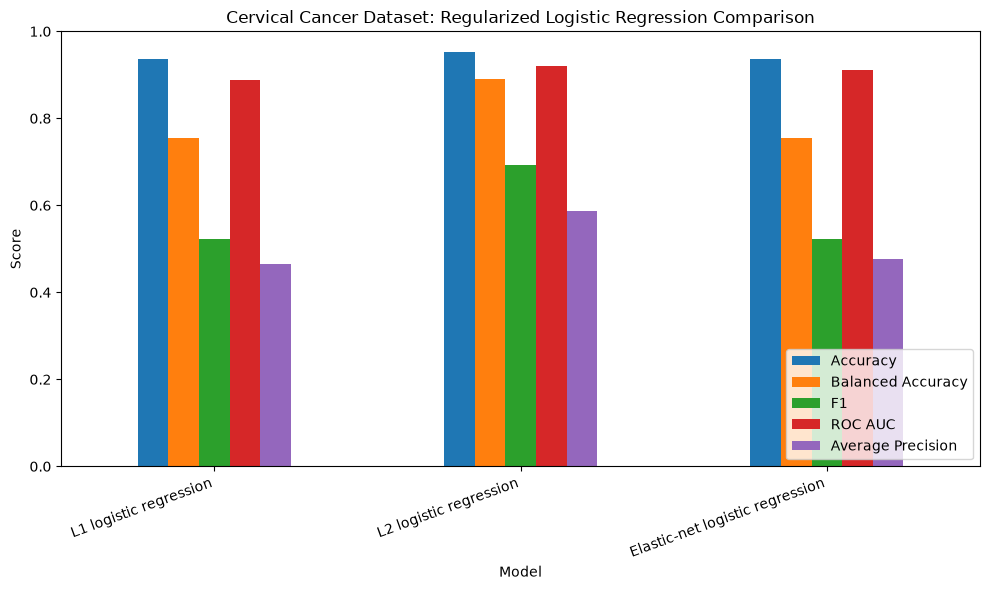

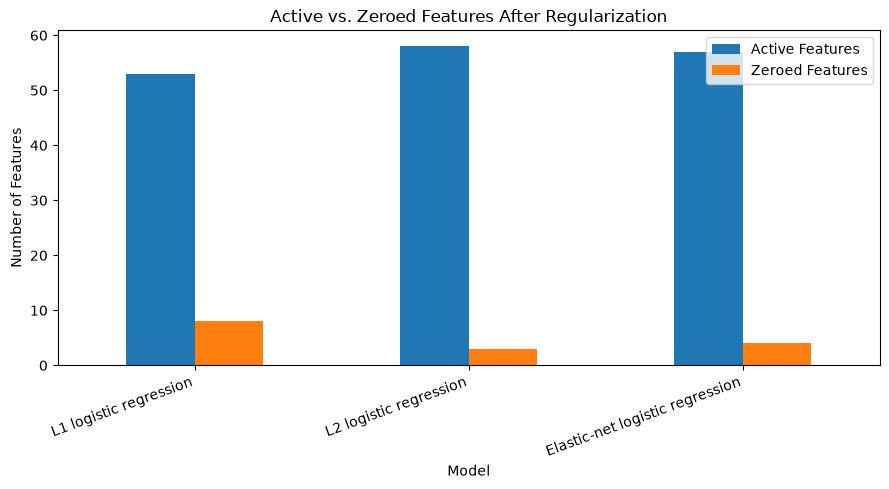

In [38]:
regularized_results_df.set_index("Model")[
    ["Accuracy", "Balanced Accuracy", "F1", "ROC AUC", "Average Precision"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Cervical Cancer Dataset: Regularized Logistic Regression Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

regularized_results_df.set_index("Model")[
    ["Active Features", "Zeroed Features"]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Active vs. Zeroed Features After Regularization")
plt.ylabel("Number of Features")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

- The first plot compares **L1, L2, and Elastic-net logistic regression**.

    - **L2** performs best across **accuracy**, **balanced accuracy**, **recall**, **F1**, **ROC AUC**, and **average precision**
    - **L1 and Elastic Net** perform more **feature selection** but **lose predictive performance**

- The second plot shows that **L1 zeroed out the most features**, while **L2 kept the most active predictors**. 

- In this dataset, **feature removal** was not helpful compared with **L2 shrinkage**

#### [Dataset 3] | *11- Inspect standardized logistic regression coefficients*

In [39]:
standardized_model = scaling_fitted_models["Standardization"]

coef_series = pd.Series(
    standardized_model.named_steps["sgd_logit"].coef_[0],
    index=X.columns
)

top_positive_biopsy = (
    coef_series
    .sort_values(ascending=False)
    .head(12)
)

top_negative_biopsy = (
    coef_series
    .sort_values(ascending=True)
    .head(12)
)

print("Top positive coefficients for Biopsy = 1")
display(top_positive_biopsy)

print("Top negative coefficients for Biopsy = 1")
display(top_negative_biopsy)

Top positive coefficients for Biopsy = 1


Schiller                      63.985993
Dx:CIN                        42.870098
Num of pregnancies            36.959746
Dx:Cancer                     32.036758
Hormonal Contraceptives       30.378681
Smokes                        17.134563
Hinselmann                    14.508495
Citology                      14.470422
Num of pregnancies_missing    11.641056
STDs:HIV                      11.621576
Dx:HPV                         6.395313
Number of sexual partners      2.040708
dtype: float64

Top negative coefficients for Biopsy = 1


Hormonal Contraceptives_missing           -71.892787
Hormonal Contraceptives (years)_missing   -71.892787
STDs:syphilis                             -41.441970
STDs: Time since first diagnosis          -20.769630
Hormonal Contraceptives (years)           -19.484115
First sexual intercourse                  -19.407528
Dx                                        -19.069806
STDs: Number of diagnosis                 -18.277081
Age                                       -15.235794
STDs:Hepatitis B                          -12.958028
STDs (number)                             -11.921771
STDs:HPV                                  -10.414274
dtype: float64

- Using the **standardized logistic regression model**, the **strongest positive coefficients** for `Biopsy = 1` were:

| Feature | Coefficient |
|---|---:|
| Schiller | 63.985993 |
| Dx:CIN | 42.870098 |
| Num of pregnancies | 36.959746 |
| Dx:Cancer | 32.036758 |
| Hormonal Contraceptives | 30.378681 |
| Smokes | 17.134563 |
| Hinselmann | 14.508495 |
| Citology | 14.470422 |
| Num of pregnancies_missing | 11.641056 |
| STDs:HIV | 11.621576 |
| Dx:HPV | 6.395313 |
| Number of sexual partners | 2.040708 |

The **strongest negative coefficients** were:

| Feature | Coefficient |
|---|---:|
| Hormonal Contraceptives_missing | -71.892787 |
| Hormonal Contraceptives (years)_missing | -71.892787 |
| STDs:syphilis | -41.441970 |
| STDs: Time since first diagnosis | -20.769630 |
| Hormonal Contraceptives (years) | -19.484115 |
| First sexual intercourse | -19.407528 |
| Dx | -19.069806 |
| STDs: Number of diagnosis | -18.277081 |
| Age | -15.235794 |
| STDs:Hepatitis B | -12.958028 |
| STDs (number) | -11.921771 |
| STDs:HPV | -10.414274 |


- The **strongest positive** coefficient was `Schiller`, which makes sense because `Schiller` is a diagnostic-related variable 

-  `Hinselmann` and `Citology` also appear among the **strongest positive predictors**.

- These coefficients are **predictive** relationships, **not causal** claims. 

- Because this dataset is **small and imbalanced**, coefficient magnitudes should be interpreted carefully.

#### [Dataset 3] | *12- Visualize top coefficients for Biopsy = 1*

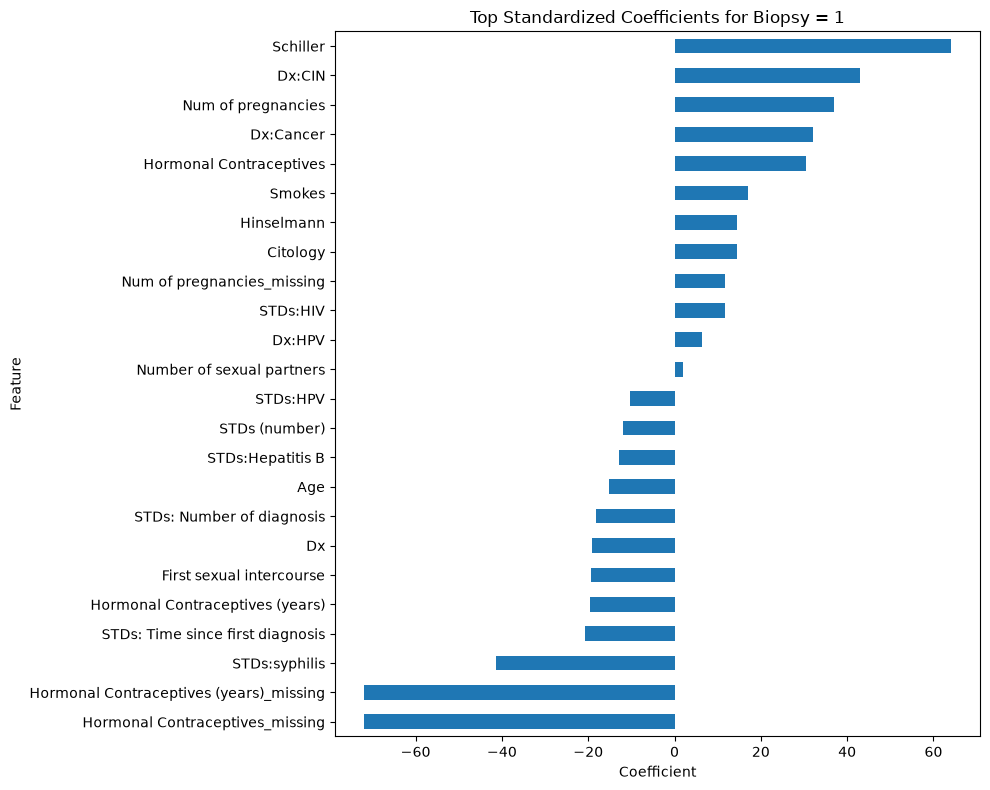

In [40]:
top_biopsy_coefficients = pd.concat([
    top_negative_biopsy,
    top_positive_biopsy
]).sort_values()

top_biopsy_coefficients.plot(
    kind="barh",
    figsize=(10, 8)
)

plt.title("Top Standardized Coefficients for Biopsy = 1")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

- The **coefficient plot** shows which **standardized predictors** push the model toward or away from predicting `Biopsy = 1`.

    - **Positive coefficients** push the model toward predicting a positive biopsy result. 
    
    - **Negative coefficients** push the model away from predicting a positive biopsy result.

- The diagnostic-related variables, especially `Schiller`, are among the strongest predictors. 

#### [Dataset 3] | *13- Classification report for best scaled model*

In [41]:
best_scaled_model_name = scaling_results_df.loc[
    scaling_results_df["F1"].idxmax(),
    "Model"
]

best_scaled_predictions = scaling_predictions[best_scaled_model_name]

print("Best scaled model by F1:", best_scaled_model_name)

print(classification_report(
    y_test,
    best_scaled_predictions,
    digits=3,
    zero_division=0
))

best_scaled_confusion = pd.DataFrame(
    confusion_matrix(y_test, best_scaled_predictions),
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(best_scaled_confusion)

Best scaled model by F1: Standardization
              precision    recall  f1-score   support

           0      0.987     0.963     0.975       161
           1      0.600     0.818     0.692        11

    accuracy                          0.953       172
   macro avg      0.794     0.890     0.834       172
weighted avg      0.962     0.953     0.957       172



,Predicted 0,Predicted 1
Actual 0,155,6
Actual 1,2,9


- The **best scaled model by F1 was the standardization model**

- The **classification report** was:

| Class | Precision | Recall | F1-score | Support |
|---:|---:|---:|---:|---:|
| 0 | 0.987 | 0.963 | 0.975 | 161 |
| 1 | 0.600 | 0.818 | 0.692 | 11 |

- Overall results:

| Metric | Value |
|---|---:|
| Accuracy | 0.953 |
| Macro F1 | 0.834 |
| Weighted F1 | 0.957 |

- The **confusion matrix** was:

|  | Predicted 0 | Predicted 1 |
|---|---:|---:|
| Actual 0 | 155 | 6 |
| Actual 1 | 2 | 9 |


- The model correctly **identified 9 of the 11 biopsy-positive cases and missed 2 positive cases**. It produced **6 false positives**.

- This is a strong result for an **imbalanced dataset**

#### [Dataset 3] | *14- Summary*

- The main result is that **scaling improved logistic regression performance**

    - The **no-scaling** model had **F1 = 0.615385**, while both **standardization and normalization** improved **F1 to 0.692308**
    
    - **Standardization** had the be**st ROC AUC and average precision**, while **normalization had the lowest log loss**.

- For **regularized logistic regression**, **L2** performed best. 

- **L1 and Elastic Net** removed more features, but their **F1** scores were lower. 

- This suggests that, for this dataset, **coefficient shrinkage was more useful than aggressive feature removal**.

- The **main takeaway** is that logistic regression is appropriate for the binary `Biopsy` target, and feature scaling matters because the predictors have very different numeric ranges.